# Detectron2 & TFOD2 | Assignment
###Assignment Code: DS-AG-024

Question 1: What is Detectron2 and how does it differ from previous object detection frameworks?
- Detectron2 is an open-source object detection and computer vision framework developed by Facebook AI Research (FAIR) that provides state-of-the-art implementations of detection and segmentation algorithms. It is built on PyTorch and is designed to be modular, flexible, and highly extensible, making it suitable for both research and production use. Detectron2 supports a wide range of tasks such as object detection, instance segmentation, semantic segmentation, panoptic segmentation, and keypoint detection, with ready-to-use implementations of popular models like Faster R-CNN, Mask R-CNN, RetinaNet, and Panoptic FPN. The framework offers strong performance, easy model configuration through YAML files, and seamless support for GPU acceleration and distributed training.

- Detectron2 differs from previous object detection frameworks such as the original Detectron (based on Caffe2), TensorFlow Object Detection API, and traditional OpenCV-based approaches in several important ways.
  - It is fully based on PyTorch, which provides dynamic computation graphs, easier debugging, and greater flexibility compared to static-graph frameworks.
  - Detectron2 introduces a highly modular design where components such as backbones, heads, datasets, and evaluators can be easily customized or replaced, enabling faster experimentation and research innovation.
  - It offers improved training speed and scalability with built-in support for multi-GPU and distributed training.
  - Detectron2 provides better dataset handling, standardized evaluation metrics (e.g., COCO evaluation), and improved code readability compared to earlier frameworks.

---

Question 2: Explain the process and importance of data annotation when working with Detectron2.
- Data annotation is the process of labeling raw images with meaningful information so that models in Detectron2 can learn to recognize and localize objects accurately. In Detectron2, annotation typically involves drawing bounding boxes, segmentation masks, or keypoints around objects of interest and assigning them correct class labels. The most commonly used annotation format is the COCO (Common Objects in Context) format, which stores image details, category information, and annotations such as bounding box coordinates and polygon masks in a structured JSON file. The annotated dataset is then registered in Detectron2 using dataset registration functions, allowing the framework to load images and labels efficiently during training and evaluation.

- The importance of data annotation in Detectron2 lies in its direct impact on model performance and reliability. High-quality, accurate annotations enable the model to learn correct spatial and semantic representations of objects, leading to better detection, segmentation, and generalization on unseen data. Poor or inconsistent annotations can introduce noise, bias, and incorrect learning patterns, significantly degrading accuracy. Since Detectron2 supports advanced tasks like instance and panoptic segmentation, precise annotations—especially pixel-level masks—are critical for achieving state-of-the-art results. Moreover, well-annotated datasets allow fair evaluation using standard metrics such as mean Average Precision (mAP).

---
Question 3: Describe the steps involved in training a custom object detection model using Detectron2.
- Training a custom object detection model using Detectron2 involves a systematic sequence of steps that ensure the model learns effectively from domain-specific data.
  - The first step is dataset preparation, where images are collected and annotated with bounding boxes, class labels, and, if required, segmentation masks, typically in COCO format. Once the dataset is ready, it must be registered in Detectron2 using dataset registration utilities so that the framework can correctly load training and validation data. Along with dataset registration, metadata such as class names is defined to support visualization and evaluation.
  - The next step is model configuration and setup. Detectron2 provides pre-defined configuration files for popular architectures such as Faster R-CNN, Mask R-CNN, and RetinaNet. A suitable base model is selected, often with pretrained weights (e.g., trained on the COCO dataset), and the configuration is customized by setting parameters such as the number of object classes, learning rate, batch size, number of training iterations, and output directory. Using pretrained models enables transfer learning, which significantly reduces training time and improves performance, especially when the custom dataset is limited in size.
  - After configuration, the training process is initiated using Detectron2's training engine, commonly the DefaultTrainer, which handles data loading, optimization, checkpointing, and evaluation. During training, the model iteratively updates its weights by minimizing the detection loss using backpropagation. Periodic evaluation on a validation dataset helps monitor performance and prevent overfitting.
  - Finally, once training is complete, the trained model is tested and deployed using the DefaultPredictor for inference on new images or videos.
  
These steps together form a complete pipeline for building an accurate and efficient custom object detection model with Detectron2.

---
Question 4: What are evaluation curves in Detectron2, and how are metrics like mAP and IoU interpreted?
- Evaluation curves in Detectron2 are graphical representations used to analyze and understand the performance of object detection and segmentation models during and after training. These curves are generated using standardized evaluation protocols, most commonly the COCO evaluation metrics, and help visualize how well a model detects and localizes objects across different confidence thresholds. Typical evaluation curves include precision-recall (PR) curves, loss curves, and learning curves, which provide insights into model accuracy, stability, and convergence. Detectron2 computes these metrics automatically during validation, enabling consistent and fair comparison between different models and training configurations.

- Two of the most important metrics used in Detectron2 are Intersection over Union (IoU) and mean Average Precision (mAP).
  - IoU measures how well a predicted bounding box overlaps with the ground-truth bounding box and is calculated as the ratio of the area of overlap to the area of union between them. Higher IoU values indicate better localization accuracy.
  - mAP, summarizes the overall detection performance by averaging the Average Precision (AP) across multiple object classes and different IoU thresholds (e.g., 0.5 to 0.95 in COCO evaluation). A higher mAP value signifies that the model is both accurately classifying objects and precisely localizing them.
  
---

Question 5: Compare Detectron2 and TFOD2 in terms of features, performance, and ease of use.
- Detectron2 and TensorFlow Object Detection API 2 (TFOD2) are two widely used frameworks for building object detection and segmentation models, each with its own strengths.
  - Features:  Detectron2 provides state-of-the-art implementations for object detection, instance segmentation, semantic segmentation, panoptic segmentation, and keypoint detection, with strong support for modern architectures such as Faster R-CNN, Mask R-CNN, RetinaNet, and Panoptic FPN. It uses a highly modular design built on PyTorch, allowing researchers to easily customize backbones, heads, and training pipelines. TFOD2, built on TensorFlow 2, also supports a broad range of detection models such as SSD, Faster R-CNN, EfficientDet, and CenterNet, and integrates well with the TensorFlow ecosystem, including TensorFlow Lite and TensorFlow Serving for deployment.
  - Performance: Detectron2 is often preferred in research and high-accuracy applications due to its efficient training, strong optimization, and consistent state-of-the-art results on benchmarks like COCO. Its PyTorch-based dynamic computation graph enables easier debugging and faster experimentation. TFOD2 offers competitive performance, especially with lightweight models optimized for mobile and edge devices, but can require more tuning to achieve top-tier accuracy on complex detection tasks.
  - Ease of use: Detectron2 is generally considered more user-friendly for researchers and practitioners familiar with PyTorch, thanks to cleaner APIs, simpler configuration files, and faster setup. TFOD2, while powerful, has a steeper learning curve due to complex configuration files and dependency management, but it excels in production and deployment scenarios within the TensorFlow ecosystem.

---

In [1]:
'''
Question 6: Write Python code to install Detectron2 and verify the installation.


'''
!python -m pip install pyyaml==5.1
import sys, os, distutils.core
!git clone 'https://github.com/facebookresearch/detectron2'
dist = distutils.core.run_setup("./detectron2/setup.py")
!python -m pip install {' '.join([f"'{x}'" for x in dist.install_requires])}
sys.path.insert(0, os.path.abspath('./detectron2'))

import torch, detectron2
!nvcc --version
TORCH_VERSION = ".".join(torch.__version__.split(".")[:2])
CUDA_VERSION = torch.__version__.split("+")[-1]
print("torch: ", TORCH_VERSION, "; cuda: ", CUDA_VERSION)
print("detectron2:", detectron2.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.2/274.2 kB 20.8 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Cloning into 'detectron2'...
remote: Enumerating objects: 15943, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 15943 (delta 5), reused 4 (delta 4), pack-reused 15931 (from 3)
Receiving objects: 100% (15943/15943), 6.71 MiB | 7.13 MiB/s, done.
Resolving deltas: 100% (11334/11334), done.
Ignoring dataclasses: markers 'python_version < "3.7"' don't match your environm

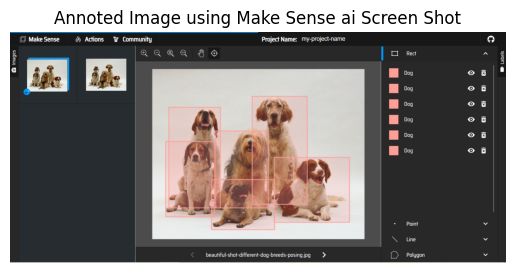

{'info': {'description': 'my-project-name'}, 'images': [], 'annotations': [{'id': 1, 'image_id': 1, 'category_id': 1, 'bbox': [0.178234, 0.648402, 0.230137, 0.442922], 'iscrowd': 0}, {'id': 2, 'image_id': 1, 'category_id': 1, 'bbox': [0.199239, 0.520548, 0.242922, 0.593607], 'iscrowd': 0}, {'id': 3, 'image_id': 1, 'category_id': 1, 'bbox': [0.427549, 0.795662, 0.297717, 0.294521], 'iscrowd': 0}, {'id': 4, 'image_id': 1, 'category_id': 1, 'bbox': [0.422983, 0.589041, 0.248402, 0.452055], 'iscrowd': 0}, {'id': 5, 'image_id': 1, 'category_id': 1, 'bbox': [0.600152, 0.477169, 0.259361, 0.634703], 'iscrowd': 0}, {'id': 6, 'image_id': 1, 'category_id': 1, 'bbox': [0.75175, 0.708904, 0.354338, 0.381279], 'iscrowd': 0}], 'categories': [{'id': 1, 'name': 'Dog'}]}


In [7]:
'''
Question 7: Annotate a dataset using any tool of your choice and convert the
annotations to COCO format for Detectron2.

'''
from PIL import Image
import json
import matplotlib.pyplot as plt

# paths to files on your PC (already available to the notebook)
image_path = "/content/dog annote.png"
json_path = "/content/dog annote coco.json"

# load and display image
image = Image.open(image_path)
plt.imshow(image)
plt.title("Annoted Image using Make Sense ai Screen Shot")
plt.axis("off")
plt.show()

# load and display json
with open(json_path, "r") as f:
    annotation = json.load(f)

print(annotation)


In [8]:
'''

Question 8: Write a script to download pretrained weights and configure paths for
training in Detectron2.

'''
from detectron2.config import get_cfg
from detectron2 import model_zoo
import os

# create config object
cfg = get_cfg()

# load base config from model zoo
cfg.merge_from_file(
    model_zoo.get_config_file(
        "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"
    )
)

# set pretrained weights (downloaded automatically)
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
    "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"
)

# dataset paths
cfg.DATASETS.TRAIN = ("my_train_dataset",)
cfg.DATASETS.TEST = ("my_val_dataset",)

# output directory for training
cfg.OUTPUT_DIR = "./output"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

print("Pretrained weights configured:")
print(cfg.MODEL.WEIGHTS)
print("Output directory:", cfg.OUTPUT_DIR)


Pretrained weights configured:
https://dl.fbaipublicfiles.com/detectron2/COCO-Detection/faster_rcnn_R_50_FPN_3x/137849458/model_final_280758.pkl
Output directory: ./output


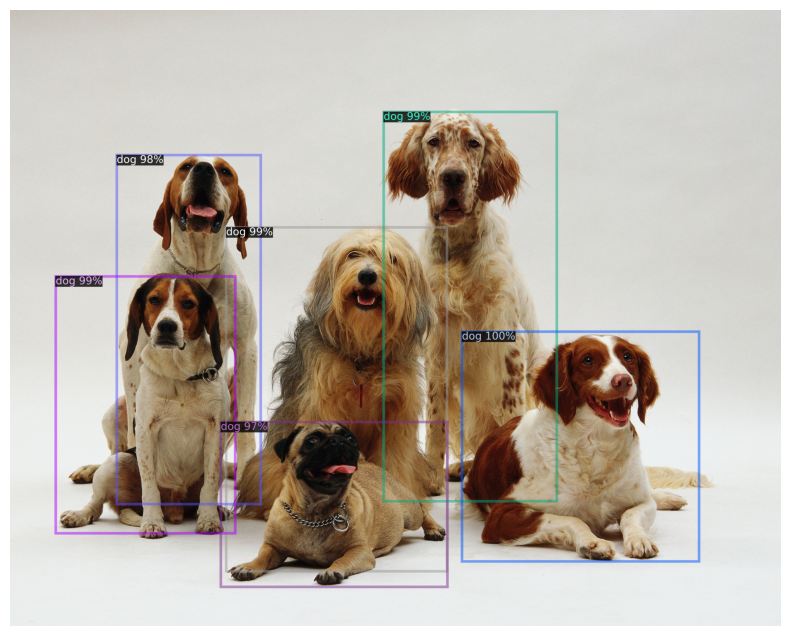

In [12]:
'''
Question 9: Show the steps and code to run inference using a trained Detectron2
model on a new image
'''

from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2 import model_zoo
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
import cv2
import matplotlib.pyplot as plt


# Loading configuration
cfg = get_cfg()
cfg.merge_from_file(
    model_zoo.get_config_file(
        "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"
    )
)
# use pretrained weights from Detectron2 model zoo
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
    "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"
)

cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
cfg.MODEL.DEVICE = "cuda"   # using cuda for GPU and cpu for cpu available

#  Creating predictor
predictor = DefaultPredictor(cfg)

# Read new image
image = cv2.imread("test image.jpg")

# Run inference
outputs = predictor(image)

# Visualizing results
v = Visualizer(
    image[:, :, ::-1],
    metadata=MetadataCatalog.get(cfg.DATASETS.TRAIN[0]),
    scale=1.0
)

result = v.draw_instance_predictions(
    outputs["instances"].to("cpu")
)

# Show output
plt.figure(figsize=(10, 8))
plt.imshow(result.get_image())
plt.axis("off")
plt.show()


---
Question 10: You are assigned to build a wildlife monitoring system to detect and track different animal species in a forest using Detectron2. Describe the end-to-end pipeline from data collection to deploying the model, and how you would handle challenges like
occlusion or nighttime detection.

- To build a wildlife monitoring system using Detectron2, the first step is data collection. Images and videos are gathered from multiple sources such as camera traps, drones, and fixed surveillance cameras installed in the forest. The data should cover different animal species, poses, distances, seasons, lighting conditions, and backgrounds to ensure good generalization.
- After collection, the data is cleaned to remove corrupted or irrelevant samples and then annotated with bounding boxes or segmentation masks for each animal species using annotation tools. The annotated data is organized in COCO format and registered in Detectron2 for training and evaluation.
- The next stage is model selection and training. A suitable Detectron2 architecture such as Faster R-CNN or Mask R-CNN with an FPN backbone is chosen due to its strong performance on multi-scale object detection. Transfer learning is applied by initializing the model with pretrained COCO weights, and the configuration is customized for the number of animal classes, learning rate, batch size, and training iterations.
- The model is trained using Detectron2's training pipeline, and performance is evaluated using metrics like mAP and IoU on a validation dataset to ensure accurate detection across species.
- Once the model is trained, inference and tracking are performed on new wildlife images and video streams. The trained Detectron2 model is used to detect animals frame by frame, and object tracking algorithms such as SORT or DeepSORT can be integrated to maintain consistent identities of animals across frames. This enables counting, movement analysis, and behavior monitoring over time. The detection results can be stored along with timestamps and GPS metadata for further ecological analysis.


- Handling real-world challenges is a critical part of the system.
  - Occlusion: It is addressed by using models with feature pyramids and instance segmentation, which help distinguish overlapping animals. Data augmentation techniques such as random cropping, flipping, and occlusion simulation during training further improve robustness.
  - Nighttime detection: Using infrared or thermal camera data is included, and training data is augmented with low light transformations. Additionally, fine-tuning the model on nighttime-specific datasets helps improve detection accuracy under poor lighting conditions.

